# Research Proposal: Modeling Daily Parking Ticket Counts in Milwaukee

### John Eckberg

## Overview
[Milwaukee plans 65,000 more parking tickets, longer meter hours to fill transportation budget gap](https://www.jsonline.com/story/news/local/milwaukee/2025/10/21/milwaukee-aims-for-550k-parking-tickets-longer-meter-hours-in-2026/86817755007/) The city of Milwaukee relies on parking ticket revenue in order to fill budget gaps, a pressing issue given the [current deficit](https://urbanmilwaukee.com/2025/03/12/mke-county-county-faces-47-million-2026-budget-deficit/) the county is facing.
This project plans to examine how daily parking ticket activity in Milwaukee varies across time and environmental conditions. Using parking citation records obtained through a Freedom of Information Act request (2014–2022), I propose to model daily ticket counts and evaluate whether temporal, weather, and holiday-related factors explain variation in enforcement volume.

## Research Question
What is the daily rate of parking tickets issued in Milwaukee, and which factors most strongly influence that rate (if any)? In particular, I propose to test whether day of week, month/seasonality, holidays, and precipitation are associated with higher or lower daily ticket counts, including by citation type.

## Hypothesis
- Null Hypothesis: day of week, month/seasonality, holidays, and precipitation do not affect daily ticket counts.
- Alternative Hypothesis: at least one temporal or environmental factor affects daily ticket counts.

## Data Sources
- **Parking citations:** Milwaukee parking ticket records, initially loaded for 2014, with fields including `ISSUENO`, `ISSUEDATE`, `LOCATIONDESC1`, and `VIODESCRIPTION`.
- **Holiday data:** U.S. holiday dates (2004–2021) pulled from Kaggle to identify atypical traffic/parking demand days.
- **Weather data:** Open-Meteo daily weather for Milwaukee, including maximum temperature, minimum temperature, precipitation, and snowfall.


## Method
The analysis would likely focus on a geographically meaningful subset of Milwaukee (e.g., downtown, Lower East Side, Deer District). Because the response variable is a daily count, I propose that the initial model choice would be a Poisson regression GLM.

### Currently Planned Features
- **Calendar effects:** day of week, month, weekend indicator, and potential seasonal terms.
- **Cyclical time encoding:** sine/cosine transforms for month and day-of-week to preserve circular structure.
- **Holiday effects:** binary `is_holiday` indicator, one-hot encoding for major holiday names.
- **Weather exposure:** `max_temp`, `min_temp`, `precipitation`, and `snowfall`; optional threshold features (e.g., heavy precipitation day).
- **Autocorrelation:** lagged ticket count features (e.g., 1-day and 7-day lags) and short rolling averages.



In [1]:
import pandas as pd
import requests
import kagglehub 
import openpyxl
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Loading in the parking data [All Years now]  --  Runs in about 10 mins

#tickets_df = pd.read_excel("data/tickets_csv/2014_parking_citations_issued_open_records_request.xlsx")
data_dir = Path("data/tickets_csv")

tickets_dfs = []

for file in sorted(data_dir.glob("*.xlsx")):
    df = pd.read_excel(file)
    tickets_dfs.append(df)

tickets = pd.concat(tickets_dfs, ignore_index=True)

tickets.sample(5)

,ISSUENO,ISSUEDATE,LOCATIONDESC1,VIODESCRIPTION
2570684,108221282,2018-03-07,7906 W ACACIA ST,PARKED IN SCHOOL ZONE
1622113,492839712,2016-08-15,1212 S 34TH ST,NIGHT PARKING
3550601,118176306,2019-11-14,5010 N 84TH ST,NIGHT PARKING - WRONG SIDE
4100636,123987264,2021-05-26,325 W STATE ST,METER PARKING VIOLATION
234577,477356714,2014-05-16,3123 N DOWNER AVE,METER PARKING VIOLATION


In [3]:
tickets.info()

<class 'pandas.DataFrame'>
RangeIndex: 4865096 entries, 0 to 4865095
Data columns (total 4 columns):
 #   Column          Dtype         
---  ------          -----         
 0   ISSUENO         int64         
 1   ISSUEDATE       datetime64[us]
 2   LOCATIONDESC1   object        
 3   VIODESCRIPTION  str           
dtypes: datetime64[us](1), int64(1), object(1), str(1)
memory usage: 148.5+ MB


In [4]:
# load in holiday data (https://www.kaggle.com/datasets/donnetew/us-holiday-dates-2004-2021)

path = kagglehub.dataset_download("donnetew/us-holiday-dates-2004-2021")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\eckbergj\.cache\kagglehub\datasets\donnetew\us-holiday-dates-2004-2021\versions\1


In [5]:
#holidays_df = pd.read_csv("C:/Users/eckbergj/.vscode/Milwaukee-Ticket-Data-Analysis/data/US Holiday Dates (2004-2021).csv")
holidays_df = pd.read_csv("data/US Holiday Dates (2004-2021).csv")

holidays_df.head(10)

,Date,Holiday,WeekDay,Month,Day,Year
0,2004-07-04,4th of July,Sunday,7,4,2004
1,2005-07-04,4th of July,Monday,7,4,2005
2,2006-07-04,4th of July,Tuesday,7,4,2006
3,2007-07-04,4th of July,Wednesday,7,4,2007
4,2008-07-04,4th of July,Friday,7,4,2008
5,2009-07-04,4th of July,Saturday,7,4,2009
6,2010-07-04,4th of July,Sunday,7,4,2010
7,2011-07-04,4th of July,Monday,7,4,2011
8,2012-07-04,4th of July,Wednesday,7,4,2012
9,2013-07-04,4th of July,Thursday,7,4,2013


In [6]:
# weather data (https://open-meteo.com/)  [extended from 2012 - 2022]
test_data = requests.get("https://archive-api.open-meteo.com/v1/archive?latitude=43.0389&longitude=-87.9065&start_date=2014-01-01&end_date=2022-12-31&daily=temperature_2m_max,temperature_2m_min,precipitation_sum,snowfall_sum&timezone=America%2FChicago")
test_data_json = test_data.json()

# minor cleaning of the weather data to get it into a dataframe
weather_df = pd.DataFrame(test_data_json['daily'])
weather_df['time'] = pd.to_datetime(weather_df['time'])
weather_df = weather_df.rename(columns={'time': 'date', 'temperature_2m_max': 'max_temp', 'temperature_2m_min': 'min_temp', 'precipitation_sum': 'precipitation','snowfall_sum': 'snowfall'})
weather_df.sample(10)


,date,max_temp,min_temp,precipitation,snowfall
1909,2019-03-25,2.3,-4.3,0.0,0.00
2762,2021-07-25,33.3,19.6,0.0,0.00
788,2016-02-28,10.0,1.5,1.6,0.00
3150,2022-08-17,24.6,17.1,0.0,0.00
1769,2018-11-05,10.3,5.8,4.4,0.00
1920,2019-04-05,9.3,2.1,0.7,0.00
2393,2020-07-21,24.3,18.3,0.1,0.00
3015,2022-04-04,10.9,1.6,5.9,0.00
1491,2018-01-31,5.6,-1.7,0.1,0.07
818,2016-03-29,6.5,1.2,0.0,0.00


In [7]:
# clean and align date keys before joining
tickets_clean = tickets.copy()
holidays_clean = holidays_df.copy()
weather_clean = weather_df.copy()

# Datetime object
tickets_clean['join_date'] = pd.to_datetime(tickets_clean['ISSUEDATE'], errors='coerce').dt.normalize()
holidays_clean['join_date'] = pd.to_datetime(holidays_clean['Date'], errors='coerce').dt.normalize()
weather_clean['join_date'] = pd.to_datetime(weather_clean['date'], errors='coerce').dt.normalize()


# merge tickets with holidays and weather on a consistent datetime key
combined_tickets_and_holidays_df = pd.merge(
    tickets_clean,
    holidays_clean,
    how='left',      # SWITCHED from 'inner' to 'left' to keep all tickets, even those without a holiday match (-> 'NAN')
    on='join_date'
 )

combined_all_df = pd.merge(
    combined_tickets_and_holidays_df,
    weather_clean,
    how='left',
    on='join_date',
    suffixes=('_holiday', '_weather')
 )

# Dropping REDUNDANT columns from the joins and the Holiday data (since many become NAN, will grab the same date info later on)
combined_all_df = combined_all_df.drop(columns=['ISSUEDATE','Date','date','WeekDay', 'Month', 'Day', 'Year'])

# sample of the combined dataframe
combined_all_df[combined_all_df['Holiday'].notnull()].sample(5)
#combined_all_df.sample(5)

,ISSUENO,LOCATIONDESC1,VIODESCRIPTION,join_date,Holiday,max_temp,min_temp,precipitation,snowfall
3136441,113894056,3540 N 16TH ST,NIGHT PARKING,2019-02-18,Washington's Birthday,-3.1,-13.6,1.8,1.26
412194,479464156,3522 S 13TH ST,NIGHT PARKING - WRONG SIDE,2014-08-30,Labor Day Weekend,24.7,21.3,0.4,0.00
77488,475278683,1602 S UNION ST,NIGHT PARKING - WRONG SIDE,2014-02-14,Valentine’s Day,-5.5,-8.6,0.0,0.00
3963119,122530870,3908 N 12TH ST,NIGHT PARKING,2021-02-15,Washington's Birthday,-13.4,-20.7,2.7,1.89
1933190,101721362,5310 W AUER AV,NIGHT PARKING - WRONG SIDE,2017-02-14,Valentine’s Day,9.2,0.2,0.1,0.00


### Feature Engineering

In [8]:
# Use Pandas DateTime to get WeekDay, Day (number), Month, Year from each ticket's join_date (ISSUEDATE)
combined_all_df['WeekDay'] = pd.to_datetime(combined_all_df['join_date'], errors='coerce').dt.day_name()
combined_all_df['Day'] = pd.to_datetime(combined_all_df['join_date'], errors='coerce').dt.day
combined_all_df['Month'] = pd.to_datetime(combined_all_df['join_date'], errors='coerce').dt.month
combined_all_df['Year'] = pd.to_datetime(combined_all_df['join_date'], errors='coerce').dt.year

combined_all_df.sample(5)

,ISSUENO,LOCATIONDESC1,VIODESCRIPTION,join_date,Holiday,max_temp,min_temp,precipitation,snowfall,WeekDay,Day,Month,Year
103927,661880785,1230 S CHAVEZ,PARKING PROHIBITED BY OFFICIAL SIGN,2014-03-01,NaN,-6.2,-11.6,5.2,3.78,Saturday,1,3,2014
2899246,111555916,120 N JEFFERSON ST,PARKED IN EXCESS OF 2 HOURS PROHIBITED,2018-09-20,NaN,27.8,17.0,11.5,0.00,Thursday,20,9,2018
936383,485258933,2840 N 41ST ST,NIGHT PARKING,2015-06-23,NaN,21.9,15.6,0.0,0.00,Tuesday,23,6,2015
3995618,122900492,384 E BAY ST,NIGHT PARKING,2021-03-13,NaN,14.4,-3.6,0.0,0.00,Saturday,13,3,2021
1755429,494369396,1742 N 24TH ST,NIGHT PARKING - WRONG SIDE,2016-11-02,NaN,14.7,11.8,18.6,0.00,Wednesday,2,11,2016


In [9]:
# See what Violation categories can be made out of the data
combined_all_df.value_counts('VIODESCRIPTION')

VIODESCRIPTION
NIGHT PARKING                                1527527
METER PARKING VIOLATION                       810877
NIGHT PARKING - WRONG SIDE                    748186
PARKING PROHIBITED BY OFFICIAL SIGN           259562
IMPROPERLY DISPLAYED VEHICLE REGISTRATION     203366
                                              ...   
TESTING IVR                                        2
TEST VIOLATION                                     1
PARKED IN RECREATIONAL AREA                        1
PARKED IN EXCESS OF 24 HOURS PROHIBITED            1
EXCEED 10-HOUR LIMIT AT METER                      1
Name: count, Length: 90, dtype: int64

In [10]:
# Feature for  Winter Storm? Inclement Weather?  Threshold can be adjusted 
combined_all_df['is_snow_emergency'] = ((combined_all_df['VIODESCRIPTION'].str.lower().str.contains('snow|emergency')) |      # in-line OR
                                        (combined_all_df['snowfall'] > 3.0)).astype(int)

# Heavy Rain?
combined_all_df['is_heavy_rain'] = (combined_all_df['precipitation'] > 2.0).astype(int)

# Meter Violation?
combined_all_df['is_meter_ticket'] = combined_all_df['VIODESCRIPTION'].str.lower().str.contains('meter').astype(int) # 1 = Meter Violation, 0 = Not a Meter Violation

# Night Violation?
combined_all_df['is_night_ticket'] = combined_all_df['VIODESCRIPTION'].str.lower().str.contains('night').astype(int) # 1 = Night Violation, 0 = Not a Night Violation

# Registration Violation?
combined_all_df['is_registration_ticket'] = combined_all_df['VIODESCRIPTION'].str.lower().str.contains('registration|unregistered').astype(int) # 1 = Registration Violation, 0 = Not a Registration Violation

# Time Violation ?
combined_all_df['is_time_ticket'] = combined_all_df['VIODESCRIPTION'].str.lower().str.contains('excess|hours|time').astype(int) # 1 = Time Violation, 0 = Not a Time Violation

# Weekend Violation?  Could add Friday as well if wanted
combined_all_df['is_weekend_ticket'] = combined_all_df['WeekDay'].str.lower().str.contains('saturday|sunday').astype(int) # 1 = Weekend Violation, 0 = Not a Weekend Violation

# Create a binary holiday flag immediately after the merge
# If 'Holiday' is not null, it becomes 1. If it is null, it becomes 0.
combined_all_df['is_holiday'] = combined_all_df['Holiday'].notnull().astype(int)

combined_all_df[combined_all_df['is_holiday'] == 1].sample(8)

,ISSUENO,LOCATIONDESC1,VIODESCRIPTION,join_date,Holiday,max_temp,min_temp,precipitation,snowfall,WeekDay,...,Month,Year,is_snow_emergency,is_heavy_rain,is_meter_ticket,is_night_ticket,is_registration_ticket,is_time_ticket,is_weekend_ticket,is_holiday
2530871,107852382,6329 W LEON TR,NIGHT PARKING,2018-02-14,Valentine’s Day,5.7,-4.7,0.0,0.00,Wednesday,...,2,2018,0,0,0,1,0,0,0,1
291702,477916666,428 E MENOMONEE ST,NIGHT PARKING,2014-06-19,Juneteenth,16.0,12.8,3.3,0.00,Thursday,...,6,2014,0,1,0,1,0,0,0,1
3617892,118673321,719 N OLD WORLD THIRD ST,TOW-AWAY ZONE (POSTED),2020-01-01,New Year's Day,4.7,-7.5,0.0,0.00,Wednesday,...,1,2020,0,0,0,0,0,0,0,1
1322953,489879165,2937 40TH ST,TOW-AWAY ZONE (BLOCKING DRIVEWAY),2016-02-15,Washington's Birthday,-2.6,-7.9,0.0,0.21,Monday,...,2,2016,0,0,0,0,0,0,0,1
3905527,121931810,4259 N TEUTONIA AV,NIGHT PARKING - WINTER RESTRICTED,2020-12-24,Christmas Eve,-3.7,-12.3,0.0,0.00,Thursday,...,12,2020,0,0,0,1,0,0,0,1
3654143,119257773,3324 N OAKLAND AV,SNOW EMERGENCY,2020-01-20,"Martin Luther King, Jr. Day",-4.4,-12.5,0.0,0.00,Monday,...,1,2020,1,0,0,0,0,0,0,1
930985,485211856,1530 S 25TH ST,IMPROPERLY DISPLAYED VEHICLE REGISTRATION,2015-06-19,Juneteenth,13.9,10.8,0.0,0.00,Friday,...,6,2015,0,0,0,0,1,0,0,1
717095,482745034,3110 N CRAMER ST,METER PARKING VIOLATION,2015-02-16,Washington's Birthday,-7.6,-14.5,0.0,0.00,Monday,...,2,2015,0,0,1,0,0,0,0,1


In [11]:
# Compressing into a Daily Format: Row per Day, with Ticket Counts and Weather/Holiday Features to be able to then predict the Daily Rate of parking tickets (and the features that affect that)
daily_summary_df = combined_all_df.groupby('join_date').agg(
    # Target Variable: COUNT of the total tickets issued that day
    total_tickets=('ISSUENO', 'count'),

    # Dataset Weather Features:
    max_temp = ('max_temp', 'max'),
    min_temp = ('min_temp', 'min'),
    precipitation = ('precipitation', 'max'),
    snowfall = ('snowfall', 'max'),
    is_snow_emergency = ('is_snow_emergency', 'max'),
    is_heavy_rain = ('is_heavy_rain', 'max'),

    # Calendar Features:
    WeekDay = ('WeekDay', 'first'),
    Year = ('Year', 'first'),
    Month = ('Month', 'first'),
    Day = ('Day', 'first'),
    is_weekend = ('is_weekend_ticket', 'max'),
    is_holiday = ('is_holiday', 'max'),

    # Count up the number of each Binary Feature type per day!
    meter_tickets_count = ('is_meter_ticket', 'sum'),
    night_tickets_count = ('is_night_ticket', 'sum'),
    registration_tickets_count = ('is_registration_ticket', 'sum'),
    time_tickets_count = ('is_time_ticket', 'sum')
).reset_index()

In [12]:
# add in LAGGED Snow Emergency Feature (if yesterday (or 2 days ago) was a snow emergency, does that affect the number of tickets issued today?)

# sort rows by date
daily_summary_df = daily_summary_df.sort_values('join_date').reset_index(drop=True)

daily_summary_df['is_snow_emergency_lag1'] = daily_summary_df['is_snow_emergency'].shift(1).fillna(0)  # Lag of 1 day ago
daily_summary_df['is_snow_emergency_lag2'] = daily_summary_df['is_snow_emergency'].shift(2).fillna(0)  # Lag of 2 days ago
#daily_summary_df['is_snow_emergency_lag3'] = daily_summary_df['is_snow_emergency'].shift(3).fillna(0)  # Lag of 3 days (72 hours after original snow emergency)

daily_summary_df.sample(10)

,join_date,total_tickets,max_temp,min_temp,precipitation,snowfall,is_snow_emergency,is_heavy_rain,WeekDay,Year,Month,Day,is_weekend,is_holiday,meter_tickets_count,night_tickets_count,registration_tickets_count,time_tickets_count,is_snow_emergency_lag1,is_snow_emergency_lag2
653,2015-10-16,1653,11.0,6.8,0.0,0.0,0,0,Friday,2015,10,16,0,0,362,827,69,113,0.0,0.0
2968,2022-02-16,2626,13.4,2.2,1.7,0.0,0,0,Wednesday,2022,2,16,0,0,397,1459,136,289,0.0,0.0
2291,2020-04-10,69,8.1,-0.4,0.0,0.0,0,0,Friday,2020,4,10,0,0,0,0,0,1,0.0,0.0
1517,2018-02-26,1071,11.2,-2.4,0.0,0.0,0,0,Monday,2018,2,26,0,0,264,469,88,70,0.0,0.0
1174,2017-03-20,1243,10.6,2.8,0.0,0.0,0,0,Monday,2017,3,20,0,0,295,595,95,73,0.0,0.0
786,2016-02-26,2512,0.9,-3.5,0.0,0.0,1,0,Friday,2016,2,26,0,0,417,1312,137,178,0.0,0.0
1634,2018-06-23,1499,21.5,12.5,0.0,0.0,0,0,Saturday,2018,6,23,1,0,155,920,88,116,0.0,0.0
1050,2016-11-16,2329,11.0,7.4,0.0,0.0,0,0,Wednesday,2016,11,16,0,0,488,1079,202,169,0.0,0.0
3124,2022-07-22,1200,33.7,19.1,0.4,0.0,0,0,Friday,2022,7,22,0,0,208,645,80,65,0.0,0.0
632,2015-09-25,2260,18.8,16.7,0.0,0.0,0,0,Friday,2015,9,25,0,0,436,1145,77,203,0.0,0.0


In [ ]:
# convert month and week features into cosine and sine transformations to capture cyclical nature 
# month_sin, month_cos, weekday_sin, weekday_cos
daily_summary_df['month_sin'] = np.sin(2 * np.pi * daily_summary_df['Month'] / 12)
daily_summary_df['month_cos'] = np.cos(2 * np.pi * daily_summary_df['Month'] / 12)
# map WeekDay to integer
weekday_map = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6}
daily_summary_df['WeekDay_num'] = daily_summary_df['WeekDay'].map(weekday_map)
daily_summary_df['weekday_sin'] = np.sin(2 * np.pi * daily_summary_df['WeekDay_num'] / 7)
daily_summary_df['weekday_cos'] = np.cos(2 * np.pi * daily_summary_df['WeekDay_num'] / 7)

# map day of month to cyclical features as well?
daily_summary_df['day_sin'] = np.sin(2 * np.pi * daily_summary_df['Day'] / 31)
daily_summary_df['day_cos'] = np.cos(2 * np.pi * daily_summary_df['Day'] / 31)

# normalize the numerical features (min-max scaling)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
numerical_features = ['rolling_30d_avg', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos']
daily_summary_df[numerical_features] = scaler.fit_transform(daily_summary_df[numerical_features])

### Visualization & Statistical Testing

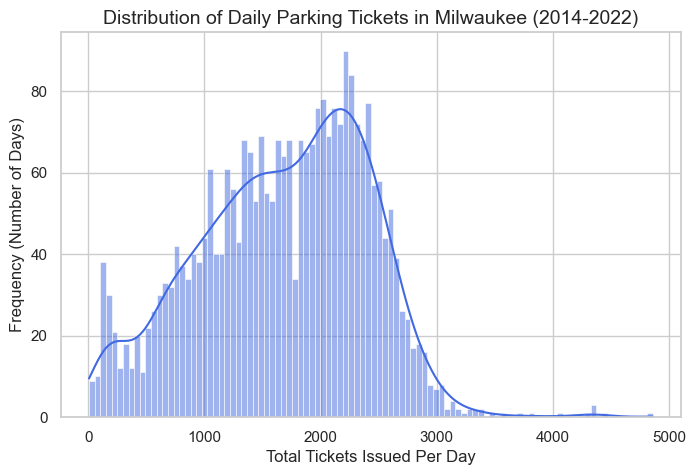

In [13]:
sns.set_theme(style="whitegrid")

# drop the year 2020 and 2021 for the histogram to see if the distribution changes without the covid years (since they are likely outliers in terms of ticket counts)
# daily_summary_no_covid_df = daily_summary_df[~daily_summary_df['Year'].isin([2020, 2021, 2022])]
daily_summary_no_sunday_df = daily_summary_df[~daily_summary_df['WeekDay'].isin(['Sunday'])]

# Histogram Plot of the Distribution of Total Daily Tickets -> show Right Skewed Tail
plt.figure(figsize=(8, 5))
sns.histplot(daily_summary_no_sunday_df['total_tickets'], bins=100, kde=True, color='royalblue')


plt.title("Distribution of Daily Parking Tickets in Milwaukee (2014-2022)", fontsize=14)
plt.xlabel("Total Tickets Issued Per Day", fontsize=12)
plt.ylabel("Frequency (Number of Days)", fontsize=12)
plt.show()

Temporal (Time) Features

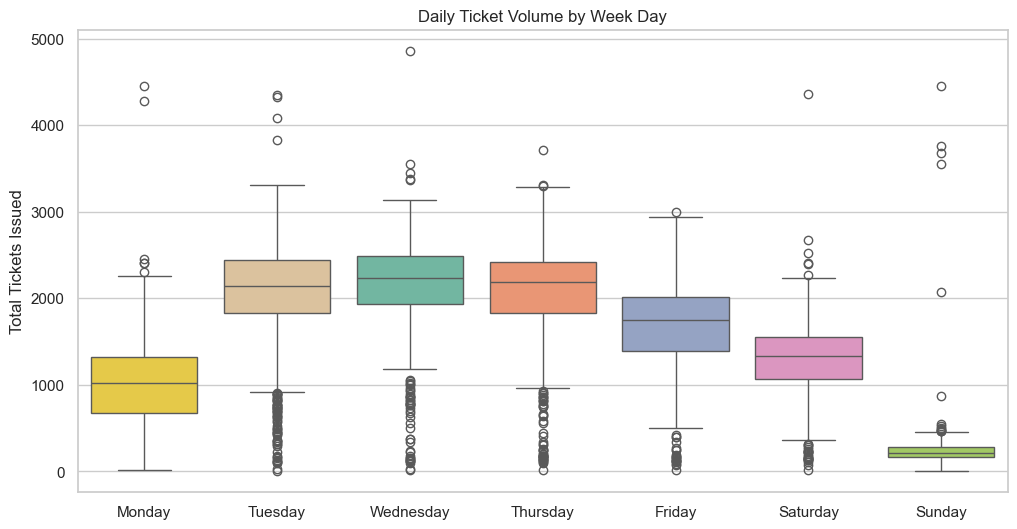

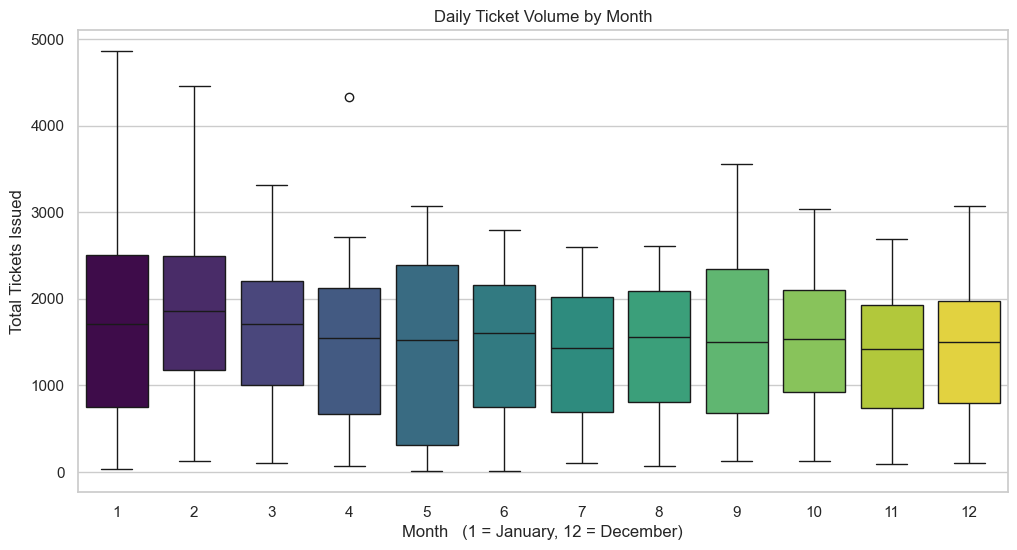

In [14]:
# WeekDay	Year	Month	Day	 is_weekend	is_holiday  
temporal_cols = ['WeekDay', 'Year', 'Month', 'Day', 'is_weekend', 'is_holiday']

# WeekDay vs. Total_Tickets (Daily Count) -> Cat. vs. Num - Boxplot
days_ordered = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(12, 6))
sns.boxplot(x='WeekDay', y='total_tickets', order=days_ordered, data=daily_summary_df, hue='WeekDay', palette='Set2')
plt.title("Daily Ticket Volume by Week Day")
plt.xlabel("")
plt.ylabel("Total Tickets Issued")
plt.show()

# Month vs. Total_Tickets
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='total_tickets',  data=daily_summary_df, hue='Month', palette='viridis', legend=False)
plt.title("Daily Ticket Volume by Month")
plt.xlabel("Month   (1 = January, 12 = December)")
plt.ylabel("Total Tickets Issued")
plt.show()


Sunday is very CLEARLY the least Ticketed day, followed by Monday!

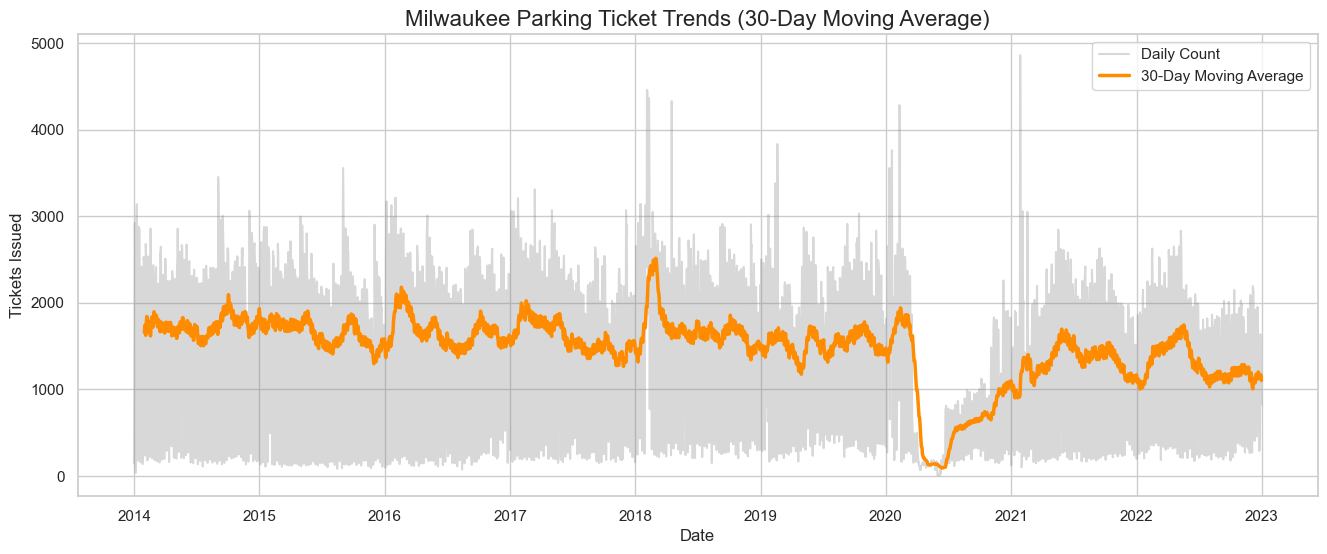

In [26]:
# Dataframe is sorted chronologically
daily_summary_df = daily_summary_df.sort_values('join_date').reset_index(drop=True)

# Calculate the 30-day moving average  [a single day's ticket total and 29 days prior to that Averaged]
daily_summary_df['rolling_30d_avg'] = daily_summary_df['total_tickets'].rolling(window=30).mean().shift(1)  # Shift by 1 to avoid look-ahead bias


plt.figure(figsize=(16, 6))
# Plot the noisy daily data lightly in the background
sns.lineplot(data=daily_summary_df, x='join_date', y='total_tickets', color='gray', alpha=0.3, label='Daily Count')

# Plot the smoothed 30-day average boldly on top
sns.lineplot(data=daily_summary_df, x='join_date', y='rolling_30d_avg', color='darkorange', linewidth=2.5, label='30-Day Moving Average')

plt.title("Milwaukee Parking Ticket Trends (30-Day Moving Average)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Tickets Issued")
plt.legend()
plt.show()

In [16]:
# Statistical Testing -- Temporal Features
from scipy.stats import kruskal

print("--- STATISTICAL TESTING: TEMPORAL FEATURES ---")
results = {}

# 1. WeekDay (multi-categorical) vs. Total Tickets [Target] (numerical) -> Kruskal-Wallis test (Bucket of tickets for each weekday)
day_groups = [daily_summary_df[daily_summary_df['WeekDay'] == day]['total_tickets'] for day in days_ordered]
stat, p_val = kruskal(*day_groups)
results["WeekDay_vs_tickets"] = (stat, p_val)

# 2. Month (categorical) vs. Total Tickets (numerical) -> Kruskal-Wallis test
month_groups = [daily_summary_df[daily_summary_df['Month'] == month]['total_tickets'] for month in range(1, 13)]
stat, p_val = kruskal(*month_groups)
results["Month_vs_tickets"] = (stat, p_val)

# 3. Year (categorical) vs. Total Tickets (numerical)
year_groups = [daily_summary_df[daily_summary_df['Year'] == year]['total_tickets'] for year in daily_summary_df['Year'].unique()]
stat, p_val = kruskal(*year_groups)
results["Year_vs_tickets"] = (stat, p_val)

# 4. Day vs. Total Tickets -> Kruskal-Wallis test
day_number_groups = [daily_summary_df[daily_summary_df['Day'] == day]['total_tickets'] for day in range(1, 32)]
stat, p_val = kruskal(*day_number_groups)
results["Day_vs_tickets"] = (stat, p_val)

# print results
for test, (stat, p_val) in results.items():
    print(f"{test}: Kruskal-Wallis H-statistic = {stat:.3f}, p-value = {p_val:.3g}")

from scipy.stats import mannwhitneyu  # binary categorical vs. numerical
binary_results = {}

# 5. is_weekend (binary categorical - 2 groups) vs. Total Tickets (numerical) -> Mann-Whitney U test
weekend_tickets = daily_summary_df[daily_summary_df['is_weekend'] == 1]['total_tickets']
weekday_tickets = daily_summary_df[daily_summary_df['is_weekend'] == 0]['total_tickets']
stat, p_val = mannwhitneyu(weekend_tickets, weekday_tickets)
binary_results["is_weekend_vs_tickets"] = (stat, p_val)

# 6. is_holiday (binary categorical - 2 groups) vs. Total Tickets (numerical) -> Mann-Whitney U test
holiday_tickets = daily_summary_df[daily_summary_df['is_holiday'] == 1]['total_tickets']
not_holiday_tickets = daily_summary_df[daily_summary_df['is_holiday'] == 0]['total_tickets']
stat, p_val = mannwhitneyu(holiday_tickets, not_holiday_tickets)
binary_results["is_holiday_vs_tickets"] = (stat, p_val)

# print results

for test, (stat, p_val) in binary_results.items():
    print(f"{test}: Mann-Whitney statistic = {stat:.3f}, p-value = {p_val:.3g}")

--- STATISTICAL TESTING: TEMPORAL FEATURES ---
WeekDay_vs_tickets: Kruskal-Wallis H-statistic = 1838.493, p-value = 0
Month_vs_tickets: Kruskal-Wallis H-statistic = 61.101, p-value = 5.78e-09
Year_vs_tickets: Kruskal-Wallis H-statistic = 387.142, p-value = 1.05e-78
Day_vs_tickets: Kruskal-Wallis H-statistic = 21.845, p-value = 0.86
is_weekend_vs_tickets: Mann-Whitney statistic = 348076.500, p-value = 7.82e-207
is_holiday_vs_tickets: Mann-Whitney statistic = 129111.000, p-value = 8.79e-21


Violation Sub-Count Features

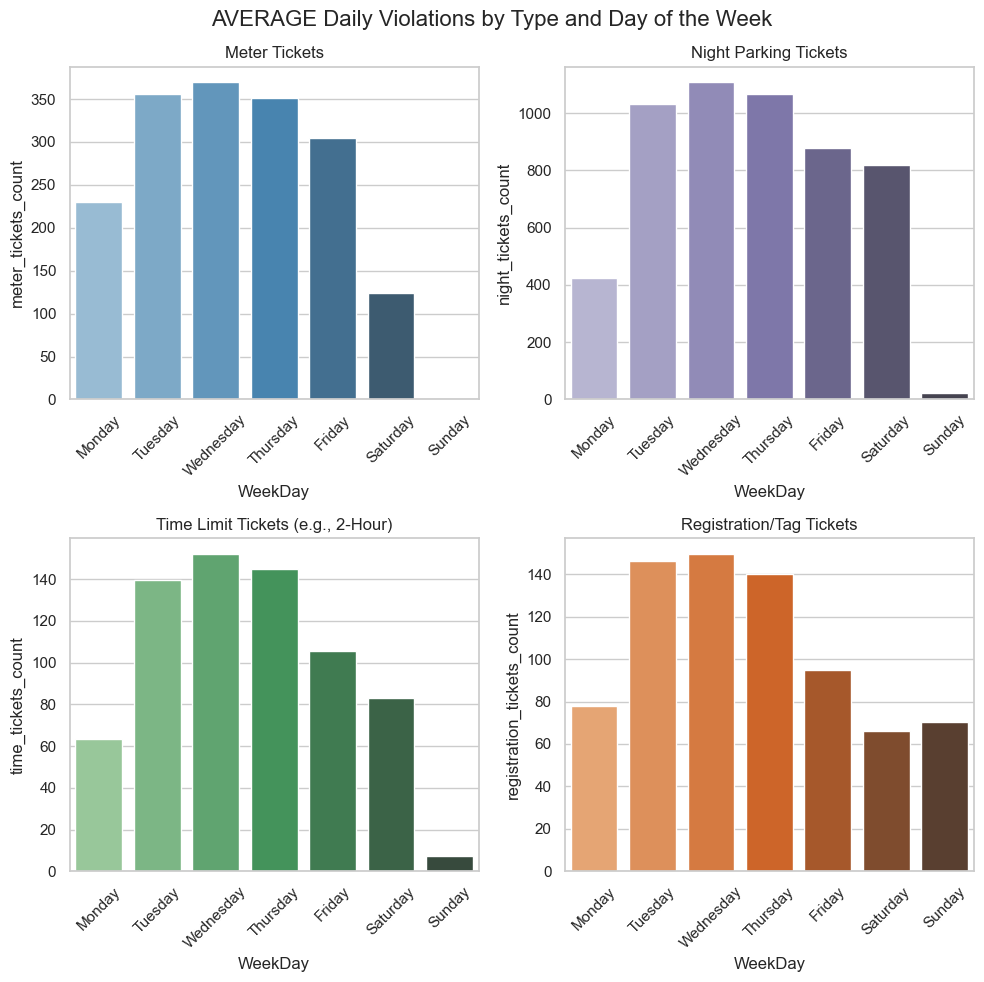

In [17]:
# Group by weekday and calculate the mean (single average number for each day)  for each sub-count
sub_counts = ['meter_tickets_count', 'night_tickets_count', 'time_tickets_count', 'registration_tickets_count']
sub_counts_grouped = daily_summary_df.groupby('WeekDay')[sub_counts].mean().reindex(days_ordered).reset_index()

# Set up the 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle('AVERAGE Daily Violations by Type and Day of the Week', fontsize=16)

# 1. Meter Tickets
sns.barplot(ax=axes[0, 0], data=sub_counts_grouped, x='WeekDay', y='meter_tickets_count', hue='WeekDay', palette='Blues_d')
axes[0, 0].set_title('Meter Tickets')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Night Tickets
sns.barplot(ax=axes[0, 1], data=sub_counts_grouped, x='WeekDay', y='night_tickets_count', hue='WeekDay', palette='Purples_d')
axes[0, 1].set_title('Night Parking Tickets')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Time Limit Tickets
sns.barplot(ax=axes[1, 0], data=sub_counts_grouped, x='WeekDay', y='time_tickets_count', hue='WeekDay', palette='Greens_d')
axes[1, 0].set_title('Time Limit Tickets (e.g., 2-Hour)')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Registration Tickets
sns.barplot(ax=axes[1, 1], data=sub_counts_grouped, x='WeekDay', y='registration_tickets_count', hue='WeekDay', palette='Oranges_d')
axes[1, 1].set_title('Registration/Tag Tickets')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [18]:
# Statistical Testing -- Violation subcount Features
# Testing to see if the (Temporal) Day of the Week significantly impacts the volume of these specific ticket violations
from scipy.stats import kruskal

print("--- STATISTICAL TESTING: Temporal Violation Sub-counts [min-targets] by Weekday ---")
results = {}

# meter_tickets_count, night_tickets_count, registration_tickets_count, time_tickets_count
for sub_count_col in sub_counts:
    groups = [daily_summary_df[daily_summary_df['WeekDay'] == day][sub_count_col] for day in days_ordered]
    stat, p_val = kruskal(*groups)
    
    print(f"{sub_count_col}_vs_WeekDay: Kruskal-Wallis H-statistic = {stat:.3f}, p-value = {p_val:.3g}")

--- STATISTICAL TESTING: Temporal Violation Sub-counts [min-targets] by Weekday ---
meter_tickets_count_vs_WeekDay: Kruskal-Wallis H-statistic = 1770.370, p-value = 0
night_tickets_count_vs_WeekDay: Kruskal-Wallis H-statistic = 1547.731, p-value = 0
time_tickets_count_vs_WeekDay: Kruskal-Wallis H-statistic = 1421.070, p-value = 6.64e-304
registration_tickets_count_vs_WeekDay: Kruskal-Wallis H-statistic = 886.000, p-value = 3.99e-188


Weather Features

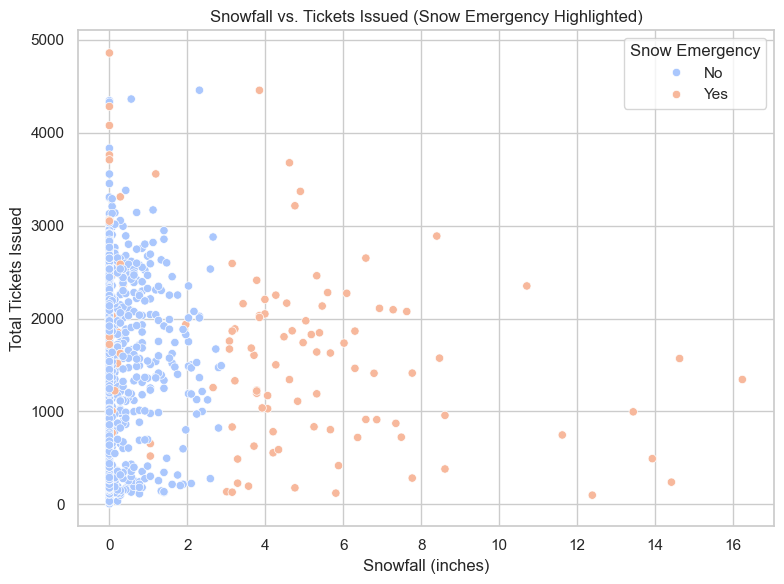

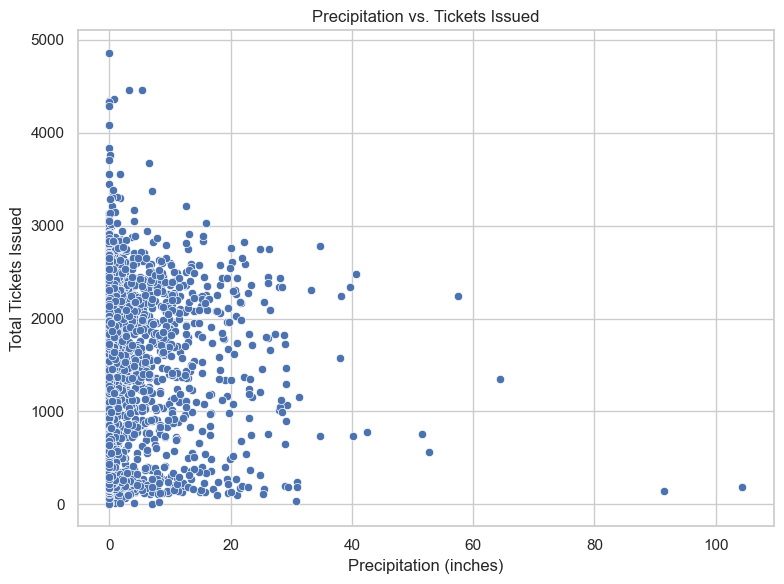

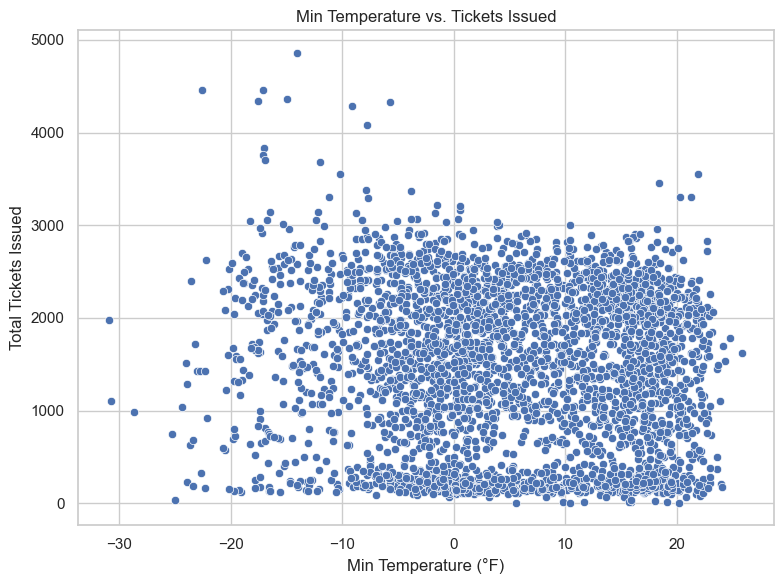

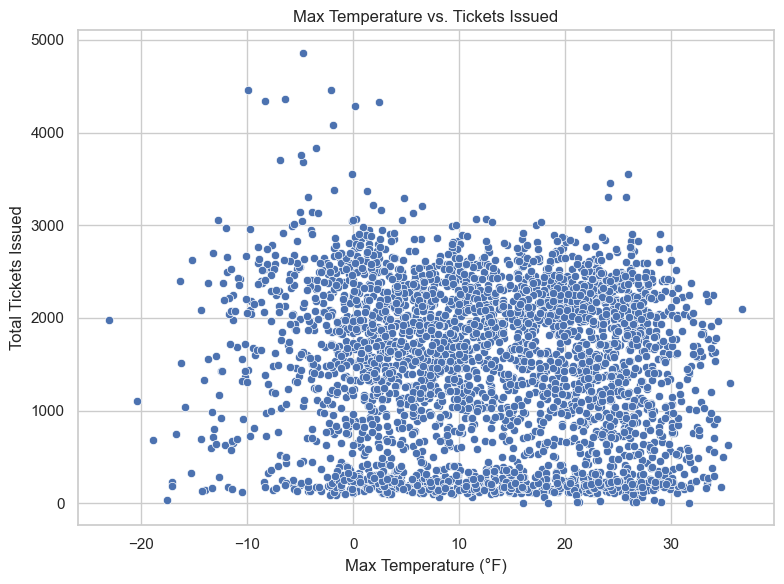

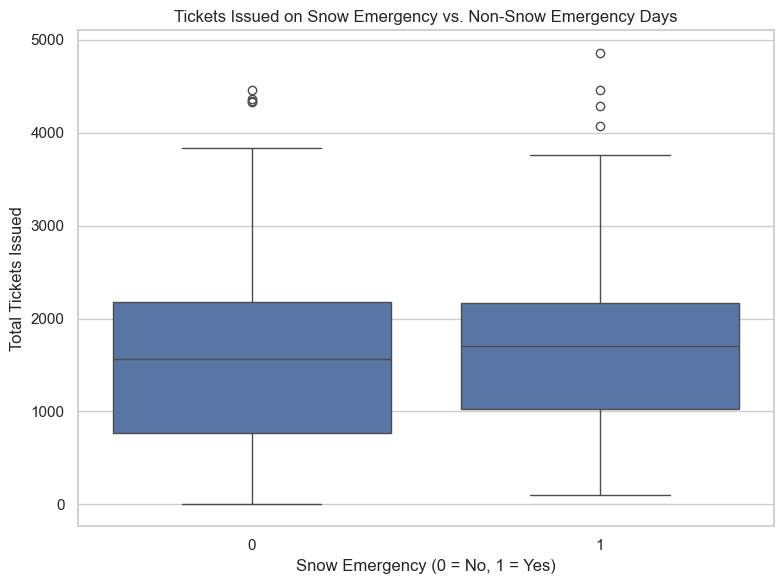

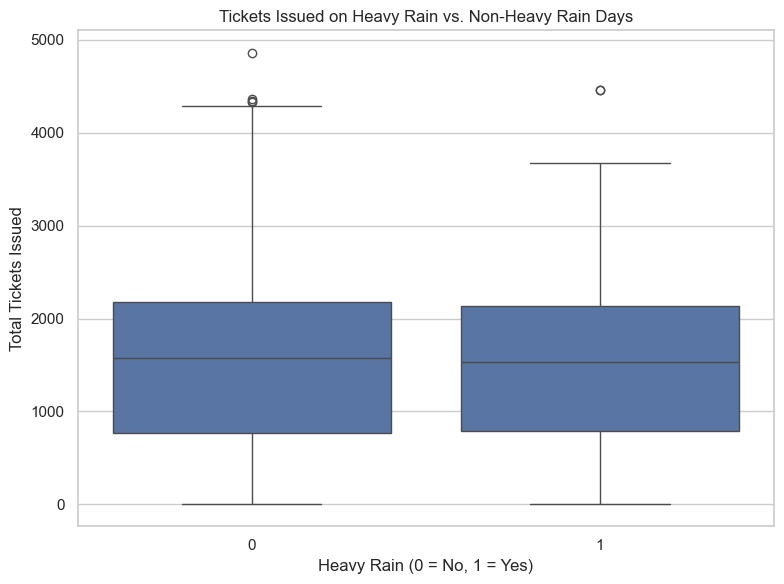

In [19]:
# Weather and tickets issued: separate plots
import matplotlib.pyplot as plt
import seaborn as sns

daily_summary_df = daily_summary_df.copy()
daily_summary_df["snow_emergency_label"] = daily_summary_df["is_snow_emergency"].map({0: "No", 1: "Yes"})

# snowfall vs. tickets issued colored by snow emergency
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=daily_summary_df,
    x="snowfall",
    y="total_tickets",
    hue="snow_emergency_label",
    palette="coolwarm"
)
plt.title("Snowfall vs. Tickets Issued (Snow Emergency Highlighted)")
plt.xlabel("Snowfall (inches)")
plt.ylabel("Total Tickets Issued")
plt.legend(title="Snow Emergency")
plt.tight_layout()
plt.show()

# precipitation vs. tickets issued
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=daily_summary_df,
    x="precipitation",
    y="total_tickets"
)
plt.title("Precipitation vs. Tickets Issued")
plt.xlabel("Precipitation (inches)")
plt.ylabel("Total Tickets Issued")
plt.tight_layout()
plt.show()

# Min temp vs. tickets issued
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=daily_summary_df,
    x="min_temp",
    y="total_tickets"
)
plt.title("Min Temperature vs. Tickets Issued")
plt.xlabel("Min Temperature (°F)")
plt.ylabel("Total Tickets Issued")
plt.tight_layout()
plt.show()

# Max temp vs. tickets issued
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=daily_summary_df,
    x="max_temp",
    y="total_tickets"
)
plt.title("Max Temperature vs. Tickets Issued")
plt.xlabel("Max Temperature (°F)")
plt.ylabel("Total Tickets Issued")
plt.tight_layout()
plt.show()

# is_snow_emergency vs. tickets issued
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=daily_summary_df,
    x="is_snow_emergency",
    y="total_tickets"
)
plt.title("Tickets Issued on Snow Emergency vs. Non-Snow Emergency Days")
plt.xlabel("Snow Emergency (0 = No, 1 = Yes)")
plt.ylabel("Total Tickets Issued")
plt.tight_layout()
plt.show()

# is_heavy_rain vs. tickets issued
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=daily_summary_df,
    x="is_heavy_rain",
    y="total_tickets"
)
plt.title("Tickets Issued on Heavy Rain vs. Non-Heavy Rain Days")
plt.xlabel("Heavy Rain (0 = No, 1 = Yes)")
plt.ylabel("Total Tickets Issued")
plt.tight_layout()
plt.show()

In [20]:
# spearman correlations
from scipy.stats import spearmanr

results = {}

# snowfall vs. tickets
corr, pval = spearmanr(daily_summary_df["snowfall"], daily_summary_df["total_tickets"])
results["snowfall_vs_tickets"] = (corr, pval)

# precipitation vs. tickets
corr, pval = spearmanr(daily_summary_df["precipitation"], daily_summary_df["total_tickets"])
results["precipitation_vs_tickets"] = (corr, pval)

# min temp vs. tickets
corr, pval = spearmanr(daily_summary_df["min_temp"], daily_summary_df["total_tickets"])
results["min_temp_vs_tickets"] = (corr, pval)

# max temp vs. tickets
corr, pval = spearmanr(daily_summary_df["max_temp"], daily_summary_df["total_tickets"])
results["max_temp_vs_tickets"] = (corr, pval)

for test, (corr, pval) in results.items():
    print(f"{test}: Spearman correlation = {corr:.3f}, p-value = {pval:.3g}")

    
# chi-squared test for is_snow_emergency vs. total_tickets (categorize total_tickets into bins for chi-squared)
from scipy.stats import chi2_contingency

# create contingency table for is_snow_emergency and binned total_tickets
daily_summary_df["tickets_bin"] = pd.cut(daily_summary_df["total_tickets"], bins=5)
contingency_table = pd.crosstab(daily_summary_df["is_snow_emergency"], daily_summary_df["tickets_bin"])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared test for Snow Emergency vs. Total Tickets (binned): chi2 = {chi2:.3f}, p-value = {p:.3g}")

# chi-squared test for is_heavy_rain vs. total_tickets (categorize total_tickets into bins for chi-squared)
# create contingency table for is_heavy_rain and binned total_tickets
contingency_table = pd.crosstab(daily_summary_df["is_heavy_rain"], daily_summary_df["tickets_bin"])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared test for Heavy Rain vs. Total Tickets (binned): chi2 = {chi2:.3f}, p-value = {p:.3g}")

# chi-squared test for is_snow_emergency_lag1 vs. total_tickets (categorize total_tickets into bins for chi-squared)
# create contingency table for is_snow_emergency_lag1 and binned total_tickets
contingency_table = pd.crosstab(daily_summary_df["is_snow_emergency_lag1"], daily_summary_df["tickets_bin"])
chi2, p, _, _ = chi2_contingency(contingency_table)
print(f"Chi-squared test for Snow Emergency (Lag 1) vs. Total Tickets (binned): chi2 = {chi2:.3f}, p-value = {p:.3g}")

# chi-squared test for is_snow_emergency_lag2 vs. total_tickets (categorize total_tickets into bins for chi-squared)
# create contingency table for is_snow_emergency_lag2 and binned total_tickets
contingency_table = pd.crosstab(daily_summary_df["is_snow_emergency_lag2"], daily_summary_df["tickets_bin"])
chi2, p, _, _ = chi2_contingency(contingency_table)
print(f"Chi-squared test for Snow Emergency (Lag 2) vs. Total Tickets (binned): chi2 = {chi2:.3f}, p-value = {p:.3g}")

snowfall_vs_tickets: Spearman correlation = 0.015, p-value = 0.401
precipitation_vs_tickets: Spearman correlation = -0.009, p-value = 0.625
min_temp_vs_tickets: Spearman correlation = -0.066, p-value = 0.000159
max_temp_vs_tickets: Spearman correlation = -0.093, p-value = 8.39e-08
Chi-squared test for Snow Emergency vs. Total Tickets (binned): chi2 = 62.235, p-value = 9.83e-13
Chi-squared test for Heavy Rain vs. Total Tickets (binned): chi2 = 2.223, p-value = 0.695
Chi-squared test for Snow Emergency (Lag 1) vs. Total Tickets (binned): chi2 = 112.176, p-value = 2.5e-23
Chi-squared test for Snow Emergency (Lag 2) vs. Total Tickets (binned): chi2 = 48.538, p-value = 7.29e-10


### co-linearity testing

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import pandas as pd

# one-hot encode WeekDay (drop_first to avoid dummy variable trap)
X = daily_summary_df.copy()
X = pd.get_dummies(X, columns=['WeekDay'], drop_first=True)

# select only the actual potential columns for VIF
vif_features = [
    'rolling_30d_avg',
    'is_snow_emergency_lag1',
    'is_snow_emergency_lag2',
    'Month',
    'is_holiday',
    'is_weekend'
    # plus all one-hot WeekDay columns automatically added
] + [col for col in X.columns if col.startswith('WeekDay_')]

# drop rows with missing values in these columns
X_vif = X[vif_features].dropna()
# convert all columns to float
X_vif = X_vif.astype(float)

X_vif.info()

<class 'pandas.DataFrame'>
RangeIndex: 3258 entries, 29 to 3286
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   rolling_30d_avg         3258 non-null   float64
 1   is_snow_emergency_lag1  3258 non-null   float64
 2   is_snow_emergency_lag2  3258 non-null   float64
 3   Month                   3258 non-null   float64
 4   is_holiday              3258 non-null   float64
 5   is_weekend              3258 non-null   float64
 6   WeekDay_Monday          3258 non-null   float64
 7   WeekDay_Saturday        3258 non-null   float64
 8   WeekDay_Sunday          3258 non-null   float64
 9   WeekDay_Thursday        3258 non-null   float64
 10  WeekDay_Tuesday         3258 non-null   float64
 11  WeekDay_Wednesday       3258 non-null   float64
dtypes: float64(12)
memory usage: 305.6 KB


In [22]:
# calculate VIF for each feature
vif_df = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print(vif_df)

                   feature       VIF
0          rolling_30d_avg  6.200112
1   is_snow_emergency_lag1  1.127648
2   is_snow_emergency_lag2  1.129727
3                    Month  3.735810
4               is_holiday  1.068714
5               is_weekend       inf
6           WeekDay_Monday  1.726707
7         WeekDay_Saturday       inf
8           WeekDay_Sunday       inf
9         WeekDay_Thursday  1.787312
10         WeekDay_Tuesday  1.754678
11       WeekDay_Wednesday  1.785048


c:\Users\eckbergj\.vscode\Milwaukee-Ticket-Data-Analysis\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


### Modeling

In [ ]:
# loop for Negative Binomial regression with rolling window cross-validation
import numpy as np
import pandas as pd
from statsmodels.discrete.discrete_model import NegativeBinomial
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

# features to use
features = [
    'is_holiday', 'is_weekend',
    'is_snow_emergency_lag1',
    'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos', 'rolling_30d_avg'
    ]
# with one hot encoded WeekDay & month
# get dummy variables for WeekDay and Month (drop_first to avoid dummy variable trap)
# daily_summary_df = pd.get_dummies(daily_summary_df, columns=['WeekDay'], drop_first=True)
# daily_summary_df = pd.get_dummies(daily_summary_df, columns=['Month'], drop_first=True)
# features = [
#     'is_holiday', 'is_weekend',
#     'is_snow_emergency_lag1', 'is_snow_emergency_lag2',
#     'rolling_30d_avg', 'WeekDay_Friday', 'WeekDay_Monday', 
#     'WeekDay_Saturday', 'WeekDay_Sunday', 'WeekDay_Thursday', 'WeekDay_Tuesday', 'WeekDay_Wednesday']
target = 'total_tickets'

# drop 2020 (COVID-19 pandemic year) to avoid instability due to abnormal enforcement patterns?
model_df = daily_summary_df[daily_summary_df['Year'] != 2020].dropna(subset=features + [target]).copy()

# rolling window cross-validation
n_splits = 8
window_size = int(len(model_df) / (n_splits + 1))

pearson_stats = []
deviance_stats = []
nmse_scores = []  # normalized MSE
loss_values = []  # final loss function value for each window

# prepare a column for predictions (initialize with NaN)
daily_summary_df['predicted_tickets'] = np.nan

for i in range(n_splits):
    train_start = i * window_size
    train_end = train_start + window_size
    test_start = train_end
    test_end = test_start + window_size
    
    train = model_df.iloc[train_start:train_end]
    test = model_df.iloc[test_start:test_end]
    
    if len(test) == 0:
        break
    
    X_train = train[features]
    y_train = train[target]
    X_test = test[features]
    y_test = test[target]
    
    # Add intercept
    import statsmodels.api as sm
    X_train_const = sm.add_constant(X_train)
    X_test_const = sm.add_constant(X_test)
    
    # fit Negative Binomial model (with intercept)
    model = NegativeBinomial(y_train, X_train_const)
    result = model.fit(disp=0)
    y_pred = result.predict(X_test_const)
    
    # save the final loss function value (negative log-likelihood)
    loss_values.append(result.llf)
    
    # debugging print if y_pred has nans
    # The predicted_tickets column is NaN for the first year because of how rolling window cross-validation is set up

    if np.isnan(y_pred).any():
        print(f"Warning: NaNs detected in y_pred for fold {i+1}. Indices: {np.where(np.isnan(y_pred))[0]}")
    
    # remove any rows where y_test or y_pred is NaN
    valid_idx = ~(np.isnan(y_test) | np.isnan(y_pred))
    y_test_valid = y_test[valid_idx]
    y_pred_valid = y_pred[valid_idx]
    if len(y_test_valid) == 0:
        print(f"All predictions or targets are NaN for fold {i+1}, skipping this fold.")
        continue  # skip this fold if all values are NaN
    
    # pearson statistic
    mu = y_pred_valid
    alpha = result.params.get('alpha', result.scale)  # fallback if alpha not in params
    var = mu + alpha * mu**2
    pearson = np.sum((y_test_valid - mu) ** 2 / var)
    pearson_stats.append(pearson / len(y_test_valid))
    
    # deviance statistic (Negative Binomial deviance)
    y = y_test_valid.values
    mu = mu.values if hasattr(mu, 'values') else mu
    eps = 1e-10  # avoid log(0)
    deviance = 2 * np.sum(
    y * np.log((y + eps) / (mu + eps)) - (y + 1/alpha) * np.log((1 + alpha * y + eps) / (1 + alpha * mu + eps))
    )
    deviance_stats.append(deviance / len(y_test_valid))
    
    # Normalized MSE (NMSE)
    mse = mean_squared_error(y_test_valid, y_pred_valid)
    nmse = mse / np.mean(y_test_valid ** 2)
    nmse_scores.append(nmse)
    
    # write predictions into the original dataframe for the test period
    # update predicted_tickets for the test dates
    test_dates = test['join_date']
    daily_summary_df.loc[daily_summary_df['join_date'].isin(test_dates), 'predicted_tickets'] = y_pred.values

print(f"Rolling window Negative Binomial regression results (n_splits={n_splits}):")
for i, (p, d, nmse, loss) in enumerate(zip(pearson_stats, deviance_stats, nmse_scores, loss_values), 1):
    print(f"Fold {i}: Pearson/df = {p:.2f}, Deviance/df = {d:.2f}, NMSE = {nmse:.4f}, Final Log-Likelihood = {loss:.2f}")


Rolling window Negative Binomial regression results (n_splits=8):
Fold 1: Pearson/df = 1.00, Deviance/df = 1.42, NMSE = 0.1015, Final Log-Likelihood = -2568.22
Fold 2: Pearson/df = 0.66, Deviance/df = 1.04, NMSE = 0.1100, Final Log-Likelihood = -2589.26
Fold 3: Pearson/df = 0.81, Deviance/df = 0.81, NMSE = 0.0917, Final Log-Likelihood = -2564.85
Fold 4: Pearson/df = 1.37, Deviance/df = 1.15, NMSE = 0.1253, Final Log-Likelihood = -2536.77
Fold 5: Pearson/df = 0.95, Deviance/df = 1.06, NMSE = 0.1197, Final Log-Likelihood = -2539.73
Fold 6: Pearson/df = 0.82, Deviance/df = 1.15, NMSE = 0.1208, Final Log-Likelihood = -2510.18
Fold 7: Pearson/df = 0.85, Deviance/df = 1.14, NMSE = 0.0957, Final Log-Likelihood = -2473.47
Fold 8: Pearson/df = 0.83, Deviance/df = 0.96, NMSE = 0.1288, Final Log-Likelihood = -2445.34


In [45]:
# model.summary()
# model_df.head()
daily_summary_df = daily_summary_df.sort_values('join_date').reset_index(drop=True)
daily_summary_df.head(30)

,join_date,total_tickets,max_temp,min_temp,precipitation,snowfall,is_snow_emergency,is_heavy_rain,WeekDay,Year,...,rolling_30d_avg,snow_emergency_label,tickets_bin,month_sin,month_cos,weekday_sin,weekday_cos,predicted_tickets,WeekDay_num,poisson_predicted_tickets
0,2014-01-01,144,-7.6,-13.3,1.3,1.33,0,0,Wednesday,2014,...,NaN,No,"(2.148, 977.4]",0.75,0.933013,1.000000,3.568959e-01,NaN,2,NaN
1,2014-01-02,979,-8.2,-13.7,0.7,1.05,0,0,Thursday,2014,...,NaN,No,"(977.4, 1947.8]",0.75,0.933013,0.722521,5.551115e-17,NaN,3,NaN
2,2014-01-03,2920,-6.6,-17.2,0.0,0.00,0,0,Friday,2014,...,NaN,No,"(2918.2, 3888.6]",0.75,0.933013,0.277479,0.000000e+00,NaN,4,NaN
3,2014-01-04,2521,0.3,-6.1,0.7,0.91,0,0,Saturday,2014,...,NaN,No,"(1947.8, 2918.2]",0.75,0.933013,0.000000,3.568959e-01,NaN,5,NaN
4,2014-01-05,129,-4.3,-16.6,1.5,1.40,0,0,Sunday,2014,...,NaN,No,"(2.148, 977.4]",0.75,0.933013,0.099031,8.019377e-01,NaN,6,NaN
5,2014-01-06,35,-17.6,-25.0,0.0,0.21,0,0,Monday,2014,...,NaN,No,"(2.148, 977.4]",0.75,0.933013,0.500000,1.000000e+00,NaN,0,NaN
6,2014-01-07,1040,-15.9,-24.4,0.0,0.00,0,0,Tuesday,2014,...,NaN,No,"(977.4, 1947.8]",0.75,0.933013,0.900969,8.019377e-01,NaN,1,NaN
7,2014-01-08,2968,-12.0,-17.4,0.0,0.00,0,0,Wednesday,2014,...,NaN,No,"(2918.2, 3888.6]",0.75,0.933013,1.000000,3.568959e-01,NaN,2,NaN
8,2014-01-09,3138,-3.9,-16.5,0.0,0.14,0,0,Thursday,2014,...,NaN,No,"(2918.2, 3888.6]",0.75,0.933013,0.722521,5.551115e-17,NaN,3,NaN
9,2014-01-10,2589,3.1,-3.8,13.4,0.14,0,1,Friday,2014,...,NaN,No,"(1947.8, 2918.2]",0.75,0.933013,0.277479,0.000000e+00,NaN,4,NaN


In [43]:
# Build Poisson Regression Model (as a baseline to Negative Binomial) with the same features and rolling window cross-validation
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

print("--- POISSON REGRESSION (BASELINE COMPARISON) ---")

# Using  exact same feature set and target

# Drop 2020 
model_df = daily_summary_df[daily_summary_df['Year'] != 2020].dropna(subset=features + [target]).copy()

n_splits = 7
window_size = int(len(model_df) / (n_splits + 1))

poisson_pearson_stats = []
poisson_deviance_stats = []
poisson_nmse_scores = []
poisson_loss_values = []

# Make a column for POISSON predictions
daily_summary_df['poisson_predicted_tickets'] = np.nan

for i in range(n_splits):
    train_start = i * window_size
    train_end = train_start + window_size
    test_start = train_end
    test_end = test_start + window_size
    
    train = model_df.iloc[train_start:train_end]
    test = model_df.iloc[test_start:test_end]
    
    if len(test) == 0:
        break
    
    X_train_const = sm.add_constant(train[features])
    y_train = train[target]
    X_test_const = sm.add_constant(test[features])
    y_test = test[target]
    
    # Fit the standard Poisson GLM
    poisson_model = sm.GLM(y_train, X_train_const, family=sm.families.Poisson())
    result = poisson_model.fit()
    y_pred = result.predict(X_test_const)
    
    poisson_loss_values.append(result.llf)
    
    valid_idx = ~(np.isnan(y_test) | np.isnan(y_pred))
    y_test_valid, y_pred_valid = y_test[valid_idx], y_pred[valid_idx]
    
    if len(y_test_valid) == 0: 
        continue
    
    # Calculate stats using statsmodels built-in properties for GLM
    # Divide by degrees of freedom to match  Pearson/df output
    df_resid = len(y_test_valid) - X_test_const.shape[1]
    
    # For out-of-sample deviance/pearson, calculate manually:
    mu = y_pred_valid
    y = y_test_valid
    
    # Poisson Pearson: Sum( (y - mu)^2 / mu )
    pearson = np.sum((y - mu)**2 / mu)
    poisson_pearson_stats.append(pearson / df_resid)
    
    # Poisson Deviance: 2 * Sum( y * log(y/mu) - (y - mu) )
    eps = 1e-10
    deviance = 2 * np.sum(y * np.log((y + eps) / (mu + eps)) - (y - mu))
    poisson_deviance_stats.append(deviance / df_resid)
    
    # NMSE
    mse = mean_squared_error(y_test_valid, y_pred_valid)
    poisson_nmse_scores.append(mse / np.mean(y_test_valid ** 2))
    
    # Save predictions
    test_dates = test['join_date']
    daily_summary_df.loc[daily_summary_df['join_date'].isin(test_dates), 'poisson_predicted_tickets'] = y_pred.values

print(f"Rolling window POISSON regression results (n_splits={n_splits}):")
for i, (p, d, nmse, loss) in enumerate(zip(poisson_pearson_stats, poisson_deviance_stats, poisson_nmse_scores, poisson_loss_values), 1):
    print(f"Fold {i}: Pearson/df = {p:.2f}, Deviance/df = {d:.2f}, NMSE = {nmse:.4f}, Final Log-Likelihood = {loss:.2f}")

--- POISSON REGRESSION (BASELINE COMPARISON) ---
Rolling window POISSON regression results (n_splits=7):
Fold 1: Pearson/df = 230.06, Deviance/df = 275.04, NMSE = 0.0871, Final Log-Likelihood = -42348.82
Fold 2: Pearson/df = 197.71, Deviance/df = 208.30, NMSE = 0.0648, Final Log-Likelihood = -43861.43
Fold 3: Pearson/df = 178.11, Deviance/df = 192.51, NMSE = 0.0680, Final Log-Likelihood = -36862.82
Fold 4: Pearson/df = 379.01, Deviance/df = 299.63, NMSE = 0.1137, Final Log-Likelihood = -34155.43
Fold 5: Pearson/df = 207.30, Deviance/df = 232.48, NMSE = 0.0978, Final Log-Likelihood = -48286.54
Fold 6: Pearson/df = 183.33, Deviance/df = 213.03, NMSE = 0.1001, Final Log-Likelihood = -37414.21
Fold 7: Pearson/df = 169.51, Deviance/df = 180.41, NMSE = 0.0995, Final Log-Likelihood = -33427.85


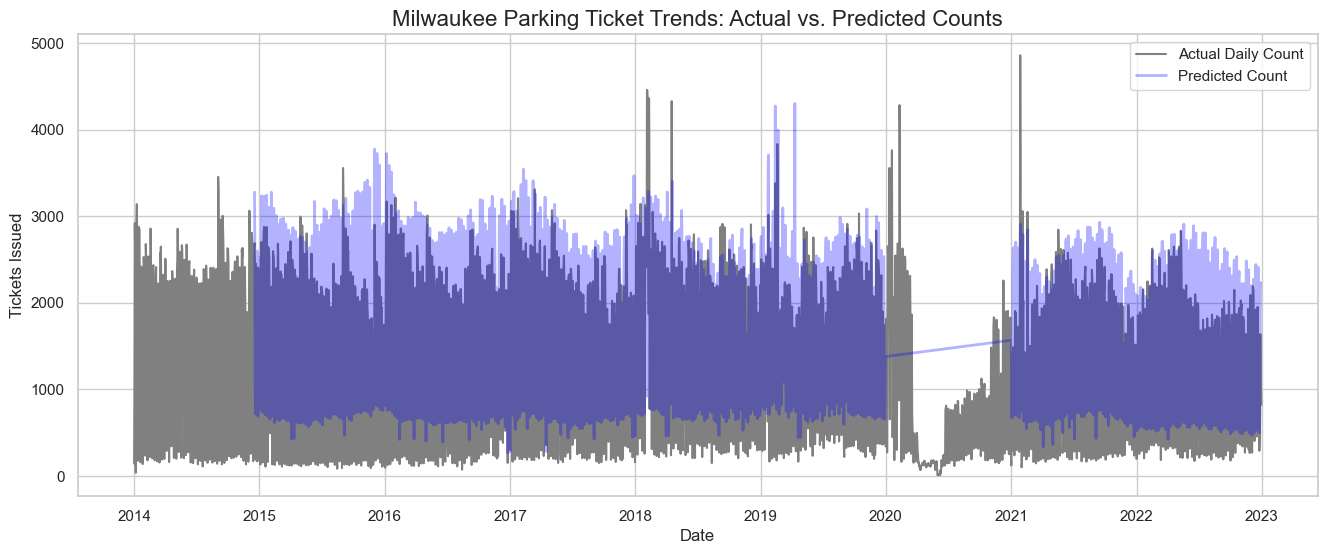

In [50]:
# overlay the logged prediction counts with the actual daily ticket values
# this didnt work very well
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ensure dataframe is sorted by date
daily_summary_df = daily_summary_df.sort_values('join_date').reset_index(drop=True)


# plot actual daily counts and overlay predicted counts (assume predicted_tickets column exists)
plt.figure(figsize=(16, 6))
sns.lineplot(data=daily_summary_df, x='join_date', y='total_tickets', color='gray', label='Actual Daily Count')
sns.lineplot(data=daily_summary_df, x='join_date', y='predicted_tickets', color='blue', alpha=0.3, linewidth=2, label='Predicted Count')

plt.title("Milwaukee Parking Ticket Trends: Actual vs. Predicted Counts", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Tickets Issued")
plt.legend()
plt.show()

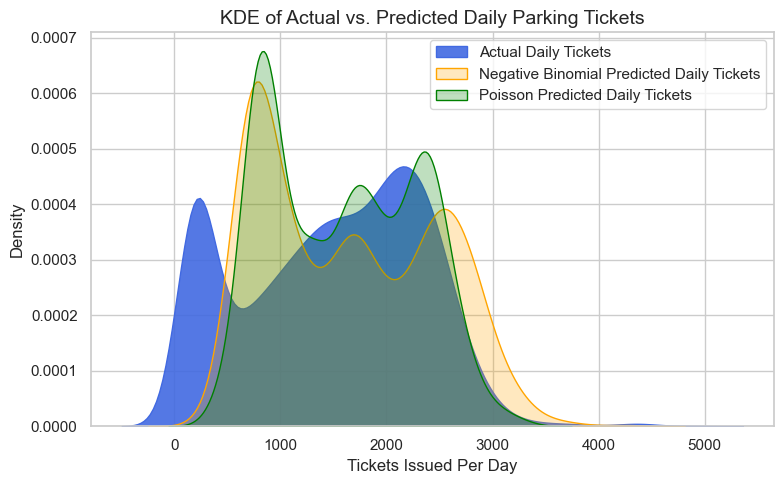

In [54]:
# overlay KDE plot for actual vs. predicted daily ticket counts for both models
plt.figure(figsize=(8, 5))
sns.kdeplot(daily_summary_df['total_tickets'].dropna(), fill=True, color='royalblue', alpha=0.9, label='Actual Daily Tickets')
sns.kdeplot(daily_summary_df['predicted_tickets'].dropna(), fill=True, color='orange', label='Negative Binomial Predicted Daily Tickets')
sns.kdeplot(daily_summary_df['poisson_predicted_tickets'].dropna(), fill=True, color='green', label='Poisson Predicted Daily Tickets')
plt.title('KDE of Actual vs. Predicted Daily Parking Tickets', fontsize=14)
plt.xlabel('Tickets Issued Per Day')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
daily_summary_df.sample(8)

,join_date,total_tickets,max_temp,min_temp,precipitation,snowfall,is_snow_emergency,is_heavy_rain,WeekDay,Year,...,is_snow_emergency_lag2,rolling_30d_avg,snow_emergency_label,tickets_bin,month_sin,month_cos,weekday_sin,weekday_cos,predicted_tickets,poisson_predicted_tickets
1621,2018-06-10,366,14.7,12.6,23.2,0.00,0,1,Sunday,2018,...,0.0,0.600041,No,"(2.148, 977.4]",0.50,0.000000,7.225209e-01,6.106227e-16,708.031806,730.559141
2991,2022-03-11,1676,1.4,-9.4,0.0,0.00,0,0,Friday,2022,...,0.0,0.587099,No,"(977.4, 1947.8]",1.00,0.500000,2.774791e-01,0.000000e+00,2211.165126,2154.739282
611,2015-09-04,2583,21.9,18.1,0.0,0.00,0,0,Friday,2015,...,0.0,0.682528,No,"(1947.8, 2918.2]",0.00,0.500000,2.774791e-01,4.996004e-16,2070.497396,2096.109000
2704,2021-05-28,1464,9.8,6.5,1.8,0.00,0,0,Friday,2021,...,0.0,0.650668,No,"(977.4, 1947.8]",0.75,0.066987,5.000000e-01,1.000000e+00,2287.260211,2202.773896
1965,2019-05-20,1088,11.7,6.2,0.0,0.00,0,0,Monday,2019,...,0.0,0.614347,No,"(977.4, 1947.8]",0.75,0.066987,9.903113e-02,8.019377e-01,1803.677024,1814.025449
199,2014-07-19,1343,21.5,17.0,0.0,0.00,0,0,Saturday,2014,...,0.0,0.611318,No,"(977.4, 1947.8]",0.25,0.066987,3.330669e-16,3.568959e-01,NaN,NaN
716,2015-12-18,1983,-0.4,-3.0,0.0,0.00,0,0,Friday,2015,...,0.0,0.583850,No,"(1947.8, 2918.2]",0.50,1.000000,2.774791e-01,3.885781e-16,1261.205827,1516.560470
2175,2019-12-16,603,0.7,-6.7,0.5,0.35,0,0,Monday,2019,...,0.0,0.542021,No,"(2.148, 977.4]",0.50,1.000000,1.000000e+00,3.568959e-01,1585.731798,1666.602760
